In [1]:
from bs4 import BeautifulSoup
import pathlib, os

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Deskriptive Analyse der TEI XML-Dateien

> Eine deskriptive Analyse in den Digital Humanities beschreibt strukturelle, quantitative oder formale Eigenschaften eines Korpus – im Fall von TEI-Dokumenten z. B. Häufigkeiten, Verteilungen, Beziehungen oder Metadaten – ohne sie inhaltlich zu interpretieren.

Beispielsweise:

* Wie häufig werden einzelne Elemente oder Deskriptoren genannt? 
* Welche Orte, Personen etc. treten wie häufig auf? 
* usw. 

In [2]:
NOTEBOOK_PATH = pathlib.Path().resolve()
DATA_DIRECTORY = NOTEBOOK_PATH / "data" / "annotated"

Hier schauen wir uns beispielhaft an, wie die Verteilung von handschriftlichen, maschinell und gemischt-geschriebenen Briefen ist. Diese Information hilft den Datensatz zu beschreiben und sich einen ersten Überblick über das Material zu verschaffen. 

In [3]:
letter_type = []

for FILE_NAME in os.listdir(DATA_DIRECTORY):

    with open(DATA_DIRECTORY / FILE_NAME, "r", encoding="utf-8") as f:
        soup = BeautifulSoup(f, "xml")
    
    support = soup.find("support").get_text(strip=True)
    letter_type.append(support)


print(letter_type)

['maschinell', 'handschriftlich', 'handschriftlich', 'gemischt', 'maschinell', 'maschinell', 'handschriftlich', 'maschinell', 'handschriftlich', 'maschinell', 'handschriftlich', 'maschinell', 'handschriftlich', 'maschinell', 'maschinell', 'maschinell', 'handschriftlich', 'handschriftlich', 'maschinell']


Für eine bessere Übersicht, können wir diese Daten mit einer der zahlreichen Visualisierungsbibliotheken in Python (in diesem Fall [seaborn](https://seaborn.pydata.org/)) graphisch darstellen:

/tmp/ipykernel_14182/191412922.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=letter_type, palette="pastel")


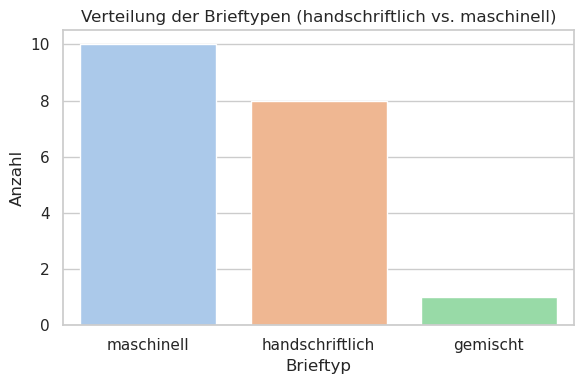

In [4]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.countplot(x=letter_type, palette="pastel")
plt.xlabel("Brieftyp")
plt.ylabel("Anzahl")
plt.title("Verteilung der Brieftypen (handschriftlich vs. maschinell)")

plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

* Was könnten weitere, interessante deskriptive Statistiken sein?
* Welche Fragen kann man auf diese Art beantworten?